# Imports and Load Data

In [36]:
import pandas as pd
import numpy as np
from numpy.linalg import inv
from scipy.stats import ttest_ind
from scipy.stats import t as tdist
import ast
import json
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.collections import PolyCollection
from datetime import datetime

In [2]:
# Load the dataset
df = pd.read_csv("Data\\classified_comment_stance_with_features.csv", encoding='utf-8')

# Display basic info
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())

# Show a small sample
display(df.sample(5))

Shape: (605822, 30)

Column Names: ['comment_id', 'self_text', 'created_time', 'author_name', 'ups', 'downs', 'score', 'post_id', 'subreddit', 'post_self_text', 'post_title', 'post_created_time', 'post_score', 'user_mentions', 'media_links', 'predicted_label', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'sentiment_score', 'factual_score', 'belief_score', 'emotionality_score', 'super_topics', 'super_similarities', 'selected_topics', 'num_selected_topics']


,comment_id,self_text,created_time,author_name,ups,downs,score,post_id,subreddit,post_self_text,...,insult,identity_hate,sentiment_score,factual_score,belief_score,emotionality_score,super_topics,super_similarities,selected_topics,num_selected_topics
352981,kvucolt,"If you oppose ethnic cleansing, how can you su...",2024-03-21 04:02:21,Sarcofago_INRI_1987,-7,0,-7,1bjtjd8,IsraelPalestine,"Honestly part of me thinks I'm a monster but ,...",...,0.020722,0.101259,-0.932092,0.327475,0.446947,0.981769,"['Arab-Israel Conflict', 'Terrorism/HAMAS', 'Z...","[0.62205863, 0.52078176, 0.48574674, 0.4632349...","['Arab-Israel Conflict', 'Terrorism/HAMAS']",2
73061,merup4k,May allah punish woever committed these attroc...,2025-02-25 21:27:55,Rainy_Wavey,13,0,13,1iy5a9q,AskMiddleEast,NaN,...,0.016312,0.045533,-0.718858,0.340868,0.458098,0.876957,"['Genocide/War Crimes', 'Pluralism/Liberal Val...","[0.5687957, 0.5231983, 0.5097825, 0.47140446, ...","['Genocide/War Crimes', 'Pluralism/Liberal Val...",3
137776,lu1hwtj,The argument that Netanyahu has dominant sway ...,2024-10-27 17:45:12,jjmmll,1,0,1,1gdan1r,IsraelPalestine,There is something that is entirely absent fro...,...,0.060328,0.186731,-0.705557,0.684266,0.081695,0.625998,"['Israel-US Relations', 'Arab-Israel Conflict'...","[0.5247526, 0.47829354, 0.4437936, 0.41726866,...",['Israel-US Relations'],1
244107,l930mw4,Let's judge terrorism by the respective action...,2024-06-18 00:27:27,OrwellianHell,1,0,1,1dhj8ce,IsraelPalestine,In evaluating whether someone is genuinely see...,...,0.057723,0.084889,-0.932861,0.455282,0.303986,0.934047,"['Terrorism/HAMAS', 'Arab-Israel Conflict', 'I...","[0.5588162, 0.5521611, 0.42415836, 0.4226084, ...","['Terrorism/HAMAS', 'Arab-Israel Conflict']",2
462770,kf8chrr,When there have been almost as many hezb kille...,2023-12-28 05:37:05,oogabong12,30,0,30,18sibgk,NonCredibleDefense,NaN,...,0.049211,0.066177,-0.881182,0.435303,0.338536,0.989236,"['Terrorism/HAMAS', 'Arab-Israel Conflict', 'C...","[0.64790505, 0.63253933, 0.5673334, 0.5079912,...","['Terrorism/HAMAS', 'Arab-Israel Conflict', 'C...",4


# Stats

In [3]:
# --- Config ---
affil_col = "predicted_label"
group_a, group_b = "Pro-Israel", "Pro-Palestine"

columns_to_keep = [
    "comment_id","created_time","author_name", "score","predicted_label","toxic","severe_toxic",
    "obscene","threat","insult","identity_hate","sentiment_score","factual_score",
    "belief_score","emotionality_score","selected_topics"
]

features = [
    "score","toxic","severe_toxic","obscene","threat","insult","identity_hate",
    "sentiment_score","factual_score","belief_score","emotionality_score"
]

df = df[columns_to_keep].dropna(subset=[affil_col])


In [4]:
# --- Helpers ---
def parse_topics(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    # Try JSON
    try:
        val = json.loads(s)
        return val if isinstance(val, list) else []
    except Exception:
        pass
    # Try Python-literal list
    try:
        val = ast.literal_eval(s)
        return val if isinstance(val, list) else []
    except Exception:
        return []

def sig_mark(p):
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))


In [10]:
# Standardize affiliation values (optional; comment out if not needed)
df[affil_col] = df[affil_col].astype(str).str.strip()

# Parse topics
df["selected_topics"] = df["selected_topics"].apply(parse_topics)

# Build exploded view for subtopic-level tests
exp = df.explode("selected_topics").rename(columns={"selected_topics":"subtopic"})
exp["subtopic"] = exp["subtopic"].fillna("")

# Include a TOTAL pseudo-topic
exp_total = exp.copy()
exp_total["subtopic"] = "TOTAL"
exp_all = pd.concat([exp, exp_total], ignore_index=True)

# Keep only the two groups
exp_all = exp_all[exp_all[affil_col].isin([group_a, group_b])].copy()

# --- Polarized confusion matrix (row-normalized) ---
# Rows AND columns are both ordered [Pro-Palestine, Pro-Israel].
# Denominators are the polarized-prediction totals (381+30=411, 40+224=264), not the
# full true-class counts (461, 309). Using the full counts drops the mass that went to
# Undefined from the numerators only, leaving rows that sum to ~0.89 / 0.85 rather
# than 1, which inflates inv(P) and overstates the correction.
P = np.array([
    [381/411, 30/411],   # True Pro-Palestine -> [pred PP, pred PI]
    [40/264, 224/264]    # True Pro-Israel    -> [pred PP, pred PI]
])

P_inv = inv(P)

# --- T-tests ---
rows = []

for topic in sorted(exp_all["subtopic"].dropna().unique(), key=lambda x: (x!="TOTAL", x)):
    topic_df = exp_all[exp_all["subtopic"] == topic]

    for feat in features:
        if feat not in topic_df.columns:
            continue

        a = pd.to_numeric(topic_df.loc[topic_df[affil_col]==group_a, feat], errors="coerce").dropna()
        b = pd.to_numeric(topic_df.loc[topic_df[affil_col]==group_b, feat], errors="coerce").dropna()

        if len(a) < 2 or len(b) < 2:
            t_obs = p_obs = diff_obs = np.nan
            t_corr = p_corr = diff_corr = np.nan
        else:
            # --- Observed ---
            mean_a = a.mean()
            mean_b = b.mean()
            diff_obs = mean_a - mean_b

            t_obs, p_obs = ttest_ind(a, b, equal_var=False, nan_policy="omit")

            # --- Corrected means ---
            # P is ordered [PP, PI]. group_a is Pro-Israel and group_b is Pro-Palestine,
            # so mu_obs must be [mean_b, mean_a] -- passing [mean_a, mean_b] applies each
            # group's correction using the other group's error rates.
            mu_obs = np.array([mean_b, mean_a])
            mu_true = P_inv @ mu_obs

            mean_b_corr = mu_true[0]   # Pro-Palestine
            mean_a_corr = mu_true[1]   # Pro-Israel
            diff_corr = mean_a_corr - mean_b_corr

            # --- Approximate corrected SE ---
            se_obs = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))

            # propagate via matrix norm scaling (conservative approximation)
            scale = np.linalg.norm(P_inv)
            se_corr = se_obs * scale

            t_corr = diff_corr / se_corr

            df_min = min(len(a)-1, len(b)-1)
            p_corr = 2 * (1 - tdist.cdf(abs(t_corr), df=df_min))

        rows.append({
            "subtopic": topic,
            "feature": feat,
            f"n_{group_a}": len(a),
            f"n_{group_b}": len(b),
            f"mean_{group_a}": np.nan if len(a)==0 else mean_a,
            f"mean_{group_b}": np.nan if len(b)==0 else mean_b,
            "diff_obs": diff_obs,
            "diff_corr": diff_corr,
            "t_obs": t_obs,
            "p_obs": p_obs,
            "p_corr": p_corr,
            "sig_obs": sig_mark(p_obs) if pd.notna(p_obs) else "",
            "sig_corr": sig_mark(p_corr) if pd.notna(p_corr) else ""
        })

res = pd.DataFrame(rows)

res_sorted = res.sort_values(
    by=["p_obs","subtopic","feature"], 
    na_position="last"
).reset_index(drop=True)

display_cols = [
    "subtopic","feature",
    f"n_{group_a}", f"n_{group_b}",
    f"mean_{group_a}", f"mean_{group_b}",
    "diff_obs","diff_corr",
    "t_obs","p_obs","p_corr",
    "sig_obs","sig_corr"
]

pretty = res_sorted[display_cols].copy()

round_cols = [
    f"mean_{group_a}", f"mean_{group_b}",
    "diff_obs","diff_corr",
    "t_obs","p_obs","p_corr"
]

pretty[round_cols] = pretty[round_cols].round(4)

with pd.option_context("display.max_rows", 200, "display.max_columns", None, "display.width", 160):
    print(f"Welch t-tests ({group_a} vs {group_b}) by subtopic (including TOTAL).")
    print("Observed and confusion-matrix–corrected p-values.")
    print("* p<.05, ** p<.01, *** p<.001")
    display(pretty)

Welch t-tests (Pro-Israel vs Pro-Palestine) by subtopic (including TOTAL).
Observed and confusion-matrix–corrected p-values.
* p<.05, ** p<.01, *** p<.001


,subtopic,feature,n_Pro-Israel,n_Pro-Palestine,mean_Pro-Israel,mean_Pro-Palestine,diff_obs,diff_corr,t_obs,p_obs,p_corr,sig_obs,sig_corr
0,Antisemitism,identity_hate,29427,30473,0.2336,0.1716,0.0620,0.0788,56.8608,0.0000,0.0000,***,***
1,Antisemitism,toxic,29427,30473,0.6522,0.7184,-0.0661,-0.1409,-57.5547,0.0000,0.0000,***,***
2,Arab-Israel Conflict,emotionality_score,260400,228709,0.6876,0.7420,-0.0544,-0.1253,-65.9398,0.0000,0.0000,***,***
3,Arab-Israel Conflict,insult,260400,228709,0.0549,0.0488,0.0061,0.0057,66.1966,0.0000,0.0000,***,***
4,Arab-Israel Conflict,obscene,260400,228709,0.0620,0.0538,0.0082,0.0084,45.8794,0.0000,0.0000,***,***
...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,Pluralism/Liberal Values,score,3517,2797,24.8249,24.2327,0.5921,-0.6685,0.2038,0.8385,0.9024,,
216,Protests,severe_toxic,546,451,0.0260,0.0257,0.0003,-0.0012,0.1818,0.8558,0.6955,,
217,Protests,threat,546,451,0.0340,0.0342,-0.0002,-0.0025,-0.1190,0.9053,0.4820,,
218,Two-State Solution,obscene,214,112,0.0691,0.0684,0.0007,-0.0034,0.0946,0.9248,0.7987,,


In [27]:
pretty[pretty['feature']=='emotionality_score']

,subtopic,feature,n_Pro-Israel,n_Pro-Palestine,mean_Pro-Israel,mean_Pro-Palestine,diff_obs,diff_corr,t_obs,p_obs,p_corr,sig_obs,sig_corr
2,Arab-Israel Conflict,emotionality_score,260400,228709,0.6876,0.7420,-0.0544,-0.1253,-65.9398,0.0000,0.0000,***,***
13,TOTAL,emotionality_score,608777,581153,0.6976,0.7496,-0.0520,-0.1224,-98.8884,0.0000,0.0000,***,***
21,Terrorism/HAMAS,emotionality_score,154451,82765,0.7164,0.7902,-0.0738,-0.1565,-64.4316,0.0000,0.0000,***,***
40,Civilian Casualties,emotionality_score,11799,17016,0.7687,0.8493,-0.0806,-0.1701,-27.6772,0.0000,0.0000,***,***
41,Zionism,emotionality_score,52617,94506,0.6628,0.7079,-0.0451,-0.1098,-27.3747,0.0000,0.0000,***,***
45,IDF,emotionality_score,11132,13283,0.6937,0.7904,-0.0967,-0.1895,-26.8040,0.0000,0.0000,***,***
56,Settlements/Ethnic Cleansing/Apartheid,emotionality_score,7970,18251,0.6210,0.7069,-0.0859,-0.1687,-20.8308,0.0000,0.0000,***,***
69,Hostages,emotionality_score,12893,4118,0.6691,0.7497,-0.0805,-0.1637,-15.9422,0.0000,0.0000,***,***
72,Palestinian Identity,emotionality_score,8314,9159,0.5020,0.5757,-0.0736,-0.1427,-15.0469,0.0000,0.0000,***,***
82,Israel-US Relations,emotionality_score,21095,46351,0.7049,0.7360,-0.0311,-0.0913,-12.8295,0.0000,0.0000,***,***


# Additional Discourse Analysis

## Engagement Analysis

In [7]:
# Ensure datetime
df["created_time"] = pd.to_datetime(df["created_time"])

# Filter to the two stance groups
df_pol = df[df["predicted_label"].isin(["Pro-Israel", "Pro-Palestine"])].copy()

# Create month period
df_pol["month"] = df_pol["created_time"].dt.to_period("M").dt.to_timestamp()

# --- Monthly counts ---
monthly_counts = (
    df_pol
    .groupby(["month", "predicted_label"])
    .size()
    .reset_index(name="comment_count")
)

# --- Monthly active users ---
monthly_users = (
    df_pol
    .groupby(["month", "predicted_label", "author_name"])
    .size()
    .reset_index(name="n_comments")
)

avg_comments_per_user = (
    monthly_users
    .groupby(["month", "predicted_label"])["n_comments"]
    .mean()
    .reset_index(name="avg_comments_per_user")
)

# Merge
monthly = pd.merge(
    monthly_counts,
    avg_comments_per_user,
    on=["month", "predicted_label"],
    how="inner"
)

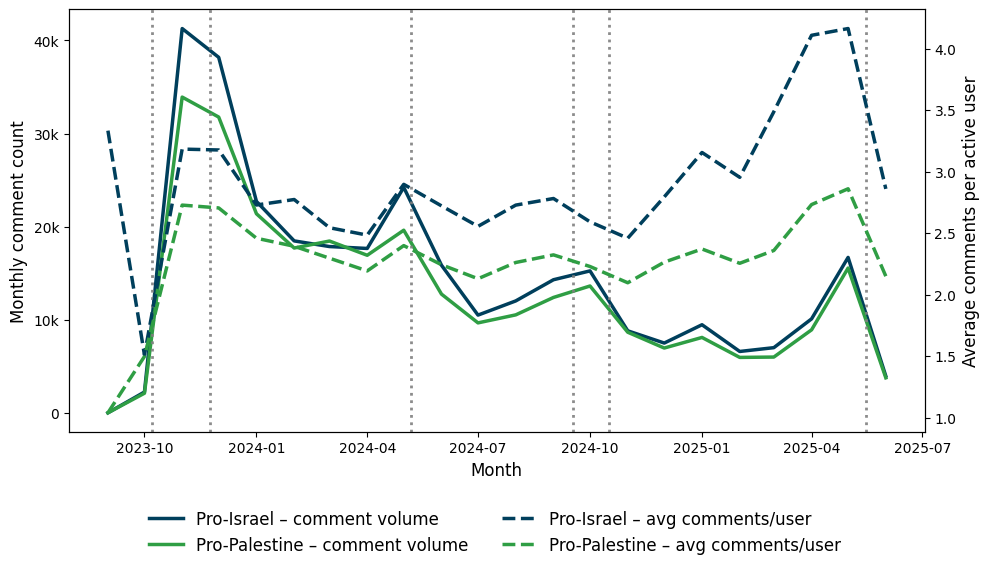

In [8]:
# Font sizes tuned for single-column figures
AXIS_LABEL_SIZE = 12
TICK_LABEL_SIZE = 10
LEGEND_SIZE = 12

colors = {
    "Pro-Israel": "#003f5c",
    "Pro-Palestine": "#2f9e44"
}

events = [
    ("Oct 7th\nAttack", datetime(2023, 10, 7)),
    ("First\nCeasefire", datetime(2023, 11, 24)),
    ("Rafah\nOperation", datetime(2024, 5, 7)),
    ("Beeper\nOperation", datetime(2024, 9, 17)),
    ("Sinwar\nAssassination", datetime(2024, 10, 17)),
    ("Merkavot\nGideon", datetime(2025, 5, 16)),
]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

for stance in ["Pro-Israel", "Pro-Palestine"]:
    data = monthly[monthly["predicted_label"] == stance]
    
    # Comment volume (solid line)
    ax1.plot(
        data["month"],
        data["comment_count"],
        label=f"{stance} – comment volume",
        color=colors[stance],
        linewidth=2.5
    )
    
    # Avg comments per user (dashed line)
    ax2.plot(
        data["month"],
        data["avg_comments_per_user"],
        label=f"{stance} – avg comments/user",
        color=colors[stance],
        linestyle="--",
        linewidth=2.5
    )

# Event lines
for _, date in events:
    ax1.axvline(
        date,
        color="gray",
        linestyle=":",
        linewidth=2,
        alpha=0.9
    )

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
)

ax1.set_ylabel("Monthly comment count", fontsize=AXIS_LABEL_SIZE)
ax2.set_ylabel("Average comments per active user", fontsize=AXIS_LABEL_SIZE)
ax1.set_xlabel("Month", fontsize=AXIS_LABEL_SIZE)
ax1.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
ax2.tick_params(axis="y", labelsize=TICK_LABEL_SIZE)

# Legend (combined)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),
    fontsize=LEGEND_SIZE
)

plt.tight_layout()
plt.show()

## Sentiment Analysis

In [13]:
# Keep polarized only
pol = df[df[affil_col].isin([group_a, group_b])].copy()

a = pol[pol[affil_col]==group_a]["sentiment_score"].dropna()
b = pol[pol[affil_col]==group_b]["sentiment_score"].dropna()

# Observed
mean_a = a.mean()
mean_b = b.mean()
diff_obs = mean_a - mean_b
t_obs, p_obs = ttest_ind(a, b, equal_var=False)

# Cohen's d
pooled_sd = np.sqrt(((a.var(ddof=1) + b.var(ddof=1)) / 2))
cohen_d = diff_obs / pooled_sd

print("Observed means:", mean_a, mean_b)
print("Observed diff:", diff_obs)
print("Observed p:", p_obs)
print("Cohen's d:", cohen_d)

# Correct means using same P_inv
# P is ordered [PP, PI]; mean_a is Pro-Israel and mean_b is Pro-Palestine.
mu_obs = np.array([mean_b, mean_a])
mu_true = P_inv @ mu_obs

mean_b_corr = mu_true[0]   # Pro-Palestine
mean_a_corr = mu_true[1]   # Pro-Israel
diff_corr = mean_a_corr - mean_b_corr

print("Corrected diff:", diff_corr)

Observed means: -0.7190188631259784 -0.7326892165436044
Observed diff: 0.013670353417626013
Observed p: 1.4323635679002183e-89
Cohen's d: 0.051894994208859645
Corrected diff: 0.0658790418085321


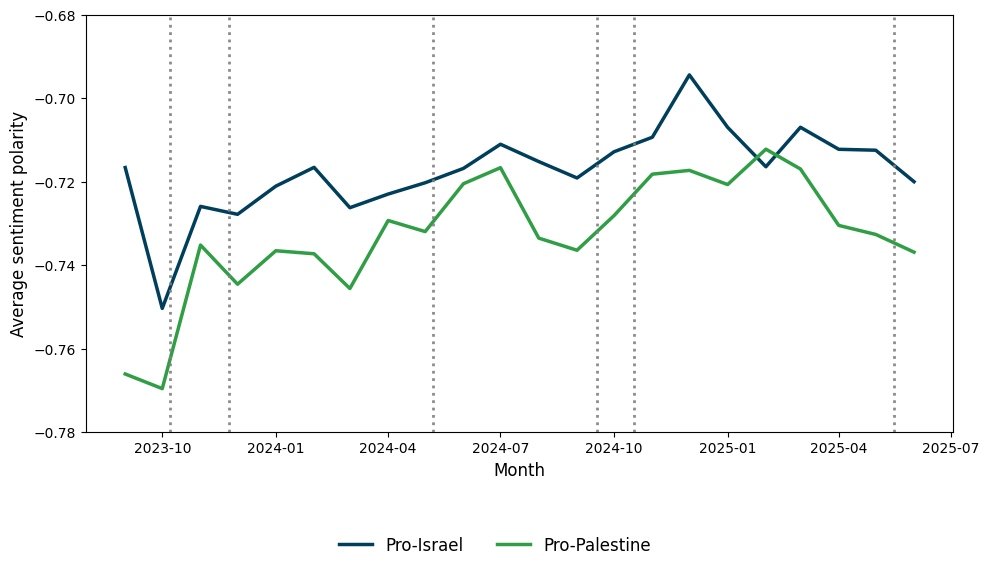

In [20]:
# --- Monthly sentiment ---
monthly_sentiment = (
    df_pol
    .groupby(["month", "predicted_label"])["sentiment_score"]
    .mean()
    .reset_index(name="avg_sentiment")
)

fig, ax = plt.subplots(figsize=(10, 5))

for stance in ["Pro-Israel", "Pro-Palestine"]:
    data = monthly_sentiment[monthly_sentiment["predicted_label"] == stance]
    
    ax.plot(
        data["month"],
        data["avg_sentiment"],
        label=stance,
        color=colors[stance],
        linewidth=2.5
    )

# Event lines (no text)
for _, date in events:
    ax.axvline(
        date,
        color="gray",
        linestyle=":",
        linewidth=2,
        alpha=0.9
    )

# Labels
ax.set_ylabel("Average sentiment polarity", fontsize=AXIS_LABEL_SIZE)
ax.set_xlabel("Month", fontsize=AXIS_LABEL_SIZE)
ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)

# Optional: fix y-limits for visual stability
ax.set_ylim(-0.78, -0.68)

# Legend below
fig.legend(
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),
    fontsize=LEGEND_SIZE
)

plt.tight_layout()
plt.show()

## Emotionality

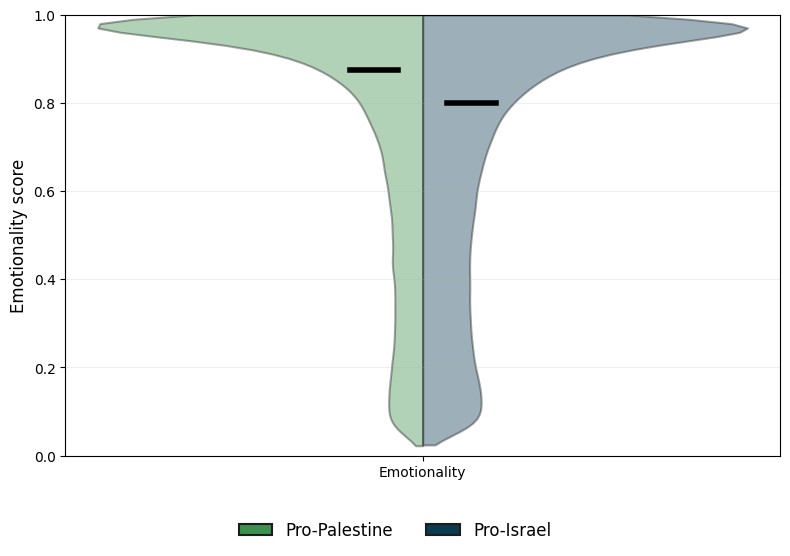

In [38]:
emo_df = df_pol[df_pol["predicted_label"].isin(["Pro-Israel", "Pro-Palestine"])].copy()
emo_df["x"] = "Emotionality"

fig, ax = plt.subplots(figsize=(8, 5))

# Split violin
sns.violinplot(
    data=emo_df,
    x="x",
    y="emotionality_score",
    hue="predicted_label",
    split=True,
    inner=None,
    cut=0,
    linewidth=1.5,
    palette=colors,
    ax=ax
)

# Make fills transparent
for artist in ax.findobj(PolyCollection):
    artist.set_alpha(0.4)

# Add clear median lines
for stance, offset in [("Pro-Palestine", -0.06), ("Pro-Israel", 0.06)]:
    vals = emo_df.loc[
        emo_df["predicted_label"] == stance,
        "emotionality_score"
    ].dropna().to_numpy()

    median = np.median(vals)

    ax.plot(
        [0 + offset - 0.03, 0 + offset + 0.03],
        [median, median],
        color="black",
        linewidth=4
    )

ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("Emotionality score", fontsize=AXIS_LABEL_SIZE)
ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
ax.grid(axis="y", alpha=0.2)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.12),
    fontsize=LEGEND_SIZE
)

plt.tight_layout()
plt.show()